# Optimization Log Copilot

**Project:** Using Large Language Models to Analyze Optimization Solver Logs  
**Course:** EN.705.605 Introduction to Generative AI  
**Student:** Jeff Ginn

---

This notebook implements the prototype pipeline for the Optimization Log Copilot project:
1. Loading and parsing optimization solver logs into structured representations
2. Feature extraction and multi-label bottleneck classification using PyTorch

## 1. Imports and Setup

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
import numpy as np
import os
import sys
import re
import json
from collections import defaultdict, Counter
from dataclasses import dataclass, asdict, field
from typing import Any, Dict, List, Optional, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd

print(f'PyTorch version= {torch.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

Device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

PyTorch version= 2.10.0
CUDA available= False


## 2. Load Solver Log Data

Load the parsed Rose solver logs from `rose_logs_parsed.csv`, which was generated
by `parse_rose_logs.py` from 8 Ramsey-type problem runs. Each row contains
structured metrics from `status.json`, `basic_metrics.json`, `problem.json`,
`detailed_metrics.json`, and `bounds.json`, plus ANSI-stripped log text from `stdout.txt`.

In [3]:
# load the parsed CSV produced by parse_rose_logs.py
df_raw = pd.read_csv('rose_logs_parsed.csv')

print(f'Loaded {len(df_raw)} solver runs x {df_raw.shape[1]} columns')
print(f'Runs: {df_raw["run_name"].tolist()}')
print(f'\nColumn groups:')
groups = {}
for c in df_raw.columns:
    prefix = c.split('_')[0]
    groups.setdefault(prefix, []).append(c)
for prefix, cols in sorted(groups.items()):
    print(f'  {prefix:12s}: {len(cols):3d} columns')

df_raw[['run_name', 'ramsey_r', 'ramsey_s', 'ramsey_n',
        'status_solution_status', 'metric_timeline_total_seconds',
        'metric_num_nodes_total', 'metric_num_lp_iterations',
        'problem_num_constraints', 'problem_num_variables',
        'derived_is_optimal']]

Loaded 8 solver runs x 212 columns
Runs: ['ramsey_r3_s3_n3', 'ramsey_r3_s3_n5', 'ramsey_r3_s3_n6', 'ramsey_r3_s4_n4', 'ramsey_r3_s4_n5', 'ramsey_r3_s4_n6', 'ramsey_r3_s4_n8', 'ramsey_r3_s4_n9']

Column groups:
  bounds      :   8 columns
  derived     :   8 columns
  detail      : 118 columns
  final       :   2 columns
  metric      :  19 columns
  num         :   1 columns
  original    :   3 columns
  presolved   :   3 columns
  problem     :  32 columns
  ramsey      :   3 columns
  root        :   2 columns
  run         :   1 columns
  solved      :   1 columns
  stages      :   1 columns
  status      :   8 columns
  stdout      :   1 columns
  termination :   1 columns


,run_name,ramsey_r,ramsey_s,ramsey_n,status_solution_status,metric_timeline_total_seconds,metric_num_nodes_total,metric_num_lp_iterations,problem_num_constraints,problem_num_variables,derived_is_optimal
0,ramsey_r3_s3_n3,3,3,3,optimal,0.058653,0,0,3,4,1
1,ramsey_r3_s3_n5,3,3,5,optimal,0.060182,3,9,21,11,1
2,ramsey_r3_s3_n6,3,3,6,no_solution,1.220350,39,37741,41,16,0
3,ramsey_r3_s4_n4,3,4,4,optimal,0.059897,1,0,6,7,1
4,ramsey_r3_s4_n5,3,4,5,optimal,0.057027,1,1,16,11,1
5,ramsey_r3_s4_n6,3,4,6,optimal,0.181377,3,9,36,16,1
6,ramsey_r3_s4_n8,3,4,8,optimal,0.069060,3,0,127,29,1
7,ramsey_r3_s4_n9,3,4,9,no_solution,1.303412,24955,21,211,37,0


## 3. Log Parsing

The CSV contains structured metrics from the Rose solver's JSON outputs.
`SolverLogFeatures` maps CSV columns to a Python object, and adds additional features extracted from the raw log text.

In [4]:
@dataclass
class SolverLogFeatures:
    name: str
    # problem dimensions
    num_constraints: int = 0
    num_variables: int = 0
    num_nonzeros: int = 0
    num_presolved_constraints: int = 0
    num_presolved_variables: int = 0
    # solution status
    solution_status: str = ''
    termination_reason: str = ''
    objective: Optional[float] = None
    # timing
    total_time_sec: float = 0.0
    solve_time_sec: float = 0.0
    presolve_time_sec: float = 0.0
    init_time_sec: float = 0.0
    # tree search
    num_nodes_total: int = 0
    num_nodes_processed: int = 0
    num_nodes_pruned: int = 0
    num_lp_iterations: int = 0
    num_solutions_found: int = 0
    # cuts
    num_cuts_generated: int = 0
    num_cuts_applied: int = 0
    # derived
    solve_fraction: Optional[float] = None
    presolve_var_reduction: Optional[float] = None
    presolve_con_reduction: Optional[float] = None
    cut_efficiency: Optional[float] = None
    nodes_per_second: Optional[float] = None
    is_optimal: int = 0
    solved_in_presolve: int = 0
    # stdout
    stages_observed: str = ''
    root_lp_objective: Optional[float] = None
    root_lp_winner: Optional[str] = None
    stdout_clean: str = ''


def row_to_features(row: pd.Series) -> SolverLogFeatures:
    def safe(col, default=0):
        v = row.get(col, default)
        return default if pd.isna(v) else v

    return SolverLogFeatures(
        name=row['run_name'],
        num_constraints=int(safe('problem_num_constraints')),
        num_variables=int(safe('problem_num_variables')),
        num_nonzeros=int(safe('problem_num_nonzeros')),
        num_presolved_constraints=int(safe('problem_num_presolved_constraints')),
        num_presolved_variables=int(safe('problem_num_presolved_variables')),
        solution_status=str(safe('status_solution_status', '')),
        termination_reason=str(safe('status_termination_reason', '')),
        objective=safe('status_objective', None),
        total_time_sec=float(safe('metric_timeline_total_seconds')),
        solve_time_sec=float(safe('metric_timeline_solve_seconds')),
        presolve_time_sec=float(safe('metric_timeline_presolve_seconds')),
        init_time_sec=float(safe('metric_timeline_init_seconds')),
        num_nodes_total=int(safe('metric_num_nodes_total')),
        num_nodes_processed=int(safe('metric_num_nodes_processed')),
        num_nodes_pruned=int(safe('metric_num_nodes_pruned')),
        num_lp_iterations=int(safe('metric_num_lp_iterations')),
        num_solutions_found=int(safe('metric_num_solutions_found')),
        num_cuts_generated=int(safe('metric_num_cuts_generated')),
        num_cuts_applied=int(safe('metric_num_cuts_applied')),
        solve_fraction=safe('derived_solve_fraction', None),
        presolve_var_reduction=safe('derived_presolve_var_reduction', None),
        presolve_con_reduction=safe('derived_presolve_con_reduction', None),
        cut_efficiency=safe('derived_cut_efficiency', None),
        nodes_per_second=safe('derived_nodes_per_second', None),
        is_optimal=int(safe('derived_is_optimal')),
        solved_in_presolve=int(safe('solved_in_presolve')),
        stages_observed=str(safe('stages_observed', '')),
        root_lp_objective=safe('root_lp_objective', None),
        root_lp_winner=str(safe('root_lp_winner', '')),
        stdout_clean=str(safe('stdout_clean', '')),
    )

In [5]:
# parse all rows into SolverLogFeatures objects
parsed_logs = [row_to_features(row) for _, row in df_raw.iterrows()]

for pl in parsed_logs:
    print(f'{pl.name:20s} | status={pl.solution_status:12s} | nodes={pl.num_nodes_total:>8,} '
          f'| cuts_gen={pl.num_cuts_generated:>3} | solve={pl.solve_time_sec:.4f}s '
          f'| stages={pl.stages_observed}')

ramsey_r3_s3_n3      | status=optimal      | nodes=       0 | cuts_gen=  0 | solve=0.0000s | stages=
ramsey_r3_s3_n5      | status=optimal      | nodes=       3 | cuts_gen= 10 | solve=0.0289s | stages=branch,contest,cuts,dive,strongb
ramsey_r3_s3_n6      | status=no_solution  | nodes=      39 | cuts_gen= 18 | solve=1.1864s | stages=branch,contest,cuts,dive,strongb
ramsey_r3_s4_n4      | status=optimal      | nodes=       1 | cuts_gen=  0 | solve=0.0251s | stages=branch,contest
ramsey_r3_s4_n5      | status=optimal      | nodes=       1 | cuts_gen=  0 | solve=0.0244s | stages=branch,contest
ramsey_r3_s4_n6      | status=optimal      | nodes=       3 | cuts_gen=  7 | solve=0.1485s | stages=branch,contest,cuts,dive,strongb
ramsey_r3_s4_n8      | status=optimal      | nodes=       3 | cuts_gen= 28 | solve=0.0352s | stages=branch,contest,cuts,dive,strongb
ramsey_r3_s4_n9      | status=no_solution  | nodes=  24,955 | cuts_gen= 36 | solve=1.2666s | stages=branch,contest,cuts,dive,strongb


## 4. Feature Extraction and Tabular View

Build a DataFrame from the parsed log objects, selecting the
numerical columns most relevant for bottleneck classification.

In [6]:
def features_to_dict(f: SolverLogFeatures) -> Dict[str, Any]:
    """Flatten a SolverLogFeatures into a dict suitable for a DataFrame."""
    d = asdict(f)
    # drop the full log text from the tabular view
    d.pop('stdout_clean', None)
    return d


df = pd.DataFrame([features_to_dict(x) for x in parsed_logs]).fillna(0)
df.set_index('name', inplace=True)
df

,num_constraints,num_variables,num_nonzeros,num_presolved_constraints,num_presolved_variables,solution_status,termination_reason,objective,total_time_sec,solve_time_sec,...,solve_fraction,presolve_var_reduction,presolve_con_reduction,cut_efficiency,nodes_per_second,is_optimal,solved_in_presolve,stages_observed,root_lp_objective,root_lp_winner
name,,,,,,,,,,,,,,,,,,,,,
ramsey_r3_s3_n3,3,4,7,0,0,optimal,finished,0.0,0.058653,0.000000,...,0.000000,1.000000,1.000000,0.0,0.000000,1,1,,0.0,
ramsey_r3_s3_n5,21,11,61,10,10,optimal,finished,0.0,0.060182,0.028902,...,0.480240,0.090909,0.523810,0.0,103.799587,1,0,"branch,contest,cuts,dive,strongb",-0.0,cuopt
ramsey_r3_s3_n6,41,16,121,20,15,no_solution,finished,0.0,1.220350,1.186418,...,0.972194,0.062500,0.512195,0.0,32.872066,0,0,"branch,contest,cuts,dive,strongb",-0.0,cuopt
ramsey_r3_s4_n4,6,7,19,5,6,optimal,finished,0.0,0.059897,0.025072,...,0.418586,0.142857,0.166667,0.0,39.885129,1,0,"branch,contest",-0.0,cuopt
ramsey_r3_s4_n5,16,11,61,15,10,optimal,finished,0.0,0.057027,0.024436,...,0.428492,0.090909,0.062500,0.0,40.923596,1,0,"branch,contest",-0.0,cuopt
ramsey_r3_s4_n6,36,16,151,35,15,optimal,finished,0.0,0.181377,0.148540,...,0.818957,0.062500,0.027778,0.0,20.196556,1,0,"branch,contest,cuts,dive,strongb",-0.0,cuopt
ramsey_r3_s4_n8,127,29,589,126,28,optimal,finished,0.0,0.069060,0.035244,...,0.510337,0.034483,0.007874,0.0,85.121645,1,0,"branch,contest,cuts,dive,strongb",0.0,highs
ramsey_r3_s4_n9,211,37,1009,210,36,no_solution,finished,0.0,1.303412,1.266567,...,0.971732,0.027027,0.004739,0.0,19702.865036,0,0,"branch,contest,cuts,dive,strongb",0.0,highs


## 5. Bottleneck Labeling

Heuristic rule-based labeling. These labels are used for training the classifier.

In [7]:
# bottleneck categories
BOTTLENECK_LABELS = [
    'weak_root_lp',
    'excessive_branching',
    'ineffective_cuts',
    'degeneracy',
    'presolve_weakness',
]
K = len(BOTTLENECK_LABELS) 


def label_log(f: SolverLogFeatures) -> np.ndarray:
    labels = np.zeros(K, dtype=np.float32)

    # weak root LP: no solution found, or solved_in_presolve=0 with high node count
    if f.solution_status == 'no_solution':
        labels[0] = 1.0
    elif f.num_nodes_total > 10 and f.num_solutions_found == 0:
        labels[0] = 1.0

    # excessive branching: large node count relative to problem size
    if f.num_nodes_total >= 100:
        labels[1] = 1.0

    # ineffective cuts: cuts generated but none applied
    if f.num_cuts_generated >= 10 and f.num_cuts_applied == 0:
        labels[2] = 1.0

    # degeneracy: high LP iterations relative to variables
    if f.num_variables > 0 and f.num_lp_iterations > 10 * f.num_variables:
        labels[3] = 1.0

    # presolve weakness: minimal reduction in variables/constraints
    if f.num_variables > 0:
        presolve_ratio = f.num_presolved_variables / f.num_variables
        if presolve_ratio > 0.95 and not f.solved_in_presolve:
            labels[4] = 1.0

    return labels


# label all parsed logs
label_matrix = np.array([label_log(f) for f in parsed_logs])

label_df = pd.DataFrame(label_matrix, columns=BOTTLENECK_LABELS, index=[f.name for f in parsed_logs])
label_df

,weak_root_lp,excessive_branching,ineffective_cuts,degeneracy,presolve_weakness
ramsey_r3_s3_n3,0.0,0.0,0.0,0.0,0.0
ramsey_r3_s3_n5,0.0,0.0,1.0,0.0,0.0
ramsey_r3_s3_n6,1.0,0.0,1.0,1.0,0.0
ramsey_r3_s4_n4,0.0,0.0,0.0,0.0,0.0
ramsey_r3_s4_n5,0.0,0.0,0.0,0.0,0.0
ramsey_r3_s4_n6,0.0,0.0,0.0,0.0,0.0
ramsey_r3_s4_n8,0.0,0.0,1.0,0.0,1.0
ramsey_r3_s4_n9,1.0,1.0,1.0,0.0,1.0


## 6. PyTorch Dataset and DataLoader

Prepare the solver log features and labels for training with PyTorch.

In [8]:
# numerical feature columns for the classifier
FEATURE_COLS = [
    'num_constraints', 'num_variables', 'num_nonzeros',
    'num_presolved_constraints', 'num_presolved_variables',
    'total_time_sec', 'solve_time_sec', 'presolve_time_sec',
    'num_nodes_total', 'num_nodes_processed', 'num_nodes_pruned',
    'num_lp_iterations', 'num_solutions_found',
    'num_cuts_generated', 'num_cuts_applied',
]
N_FEATURES = len(FEATURE_COLS)


class SolverLogDataset(Dataset):
    def __init__(self, features_df: pd.DataFrame, labels: np.ndarray):
        self.X = torch.tensor(features_df[FEATURE_COLS].values, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32)
        # z-score normalization
        self.mean = self.X.mean(dim=0)
        self.std = self.X.std(dim=0).clamp(min=1e-8)
        self.X = (self.X - self.mean) / self.std

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


ds = SolverLogDataset(df.reset_index(), label_matrix)
dl = DataLoader(ds, batch_size=2, shuffle=True)

# sanity check
x_batch, y_batch = next(iter(dl))
print(f'Feature batch shape: {x_batch.shape}')  # (B, N_FEATURES)
print(f'Label batch shape:   {y_batch.shape}')   # (B, K)

Feature batch shape: torch.Size([2, 15])
Label batch shape:   torch.Size([2, 5])


## 7. Bottleneck Classifier (PyTorch)

In the full project I will likely replace this with a transformer encoder, e.g., Big Bird.

In [9]:
class BottleneckClassifier(nn.Module):

    def __init__(self, n_input: int, n_hidden: int, n_output: int, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


# hyperparameters
N_HIDDEN = 64
EPOCHS_CLS = 200
LR_CLS = 1e-3

model_cls = BottleneckClassifier(N_FEATURES, N_HIDDEN, K).to(Device)
print(model_cls)

BottleneckClassifier(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
    (7): Sigmoid()
  )
)


In [10]:
def params_count(_net):
    return sum(p.numel() for p in _net.parameters() if p.requires_grad)

print(f'Num Params= {params_count(model_cls):,}')

Num Params= 5,509


### Training

In [11]:
%%time

criterion_cls = nn.BCELoss()
optimizer_cls = torch.optim.Adam(model_cls.parameters(), lr=LR_CLS)

loss_history = []

model_cls.train()
for epoch in range(EPOCHS_CLS):
    epoch_loss = 0.0
    for x_batch, y_batch in dl:
        x_batch = x_batch.to(Device)
        y_batch = y_batch.to(Device)

        optimizer_cls.zero_grad()
        y_pred = model_cls(x_batch)
        loss = criterion_cls(y_pred, y_batch)
        loss.backward()
        optimizer_cls.step()
        epoch_loss += loss.item()

    loss_history.append(epoch_loss)
    if (epoch + 1) % 50 == 0:
        sys.stderr.write(f'\rEpoch {epoch+1:3d}/{EPOCHS_CLS} | Loss: {epoch_loss:.4f}')
        sys.stderr.flush()

print(f'\nFinal loss: {loss_history[-1]:.4f}')

Epoch 200/200 | Loss: 0.0265


Final loss: 0.0265
CPU times: user 767 ms, sys: 277 ms, total: 1.04 s
Wall time: 2.36 s


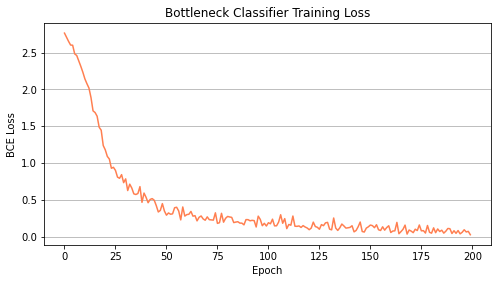

In [12]:
# training loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history, c='coral')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Bottleneck Classifier Training Loss')
plt.grid(axis='y')
plt.show()

### Inference

In [13]:
model_cls.eval()
with torch.no_grad():
    X_all = ds.X.to(Device)
    preds = model_cls(X_all).cpu().numpy()

pred_labels = (preds >= 0.5).astype(int)

pred_df = pd.DataFrame(pred_labels, columns=BOTTLENECK_LABELS, index=[f.name for f in parsed_logs])
print('Predicted bottleneck labels:')
pred_df

Predicted bottleneck labels:


,weak_root_lp,excessive_branching,ineffective_cuts,degeneracy,presolve_weakness
ramsey_r3_s3_n3,0,0,0,0,0
ramsey_r3_s3_n5,0,0,1,0,0
ramsey_r3_s3_n6,1,0,1,1,0
ramsey_r3_s4_n4,0,0,0,0,0
ramsey_r3_s4_n5,0,0,0,0,0
ramsey_r3_s4_n6,0,0,0,0,0
ramsey_r3_s4_n8,0,0,1,0,1
ramsey_r3_s4_n9,1,1,1,0,1


In [14]:
# compare predictions to heuristic labels
print('Ground truth (heuristic) labels:')
print(label_df.values)
print('\nPredicted labels:')
print(pred_df.values)
print(f'\nMatch rate: {(pred_df.values == label_df.values).mean():.2%}')

Ground truth (heuristic) labels:
[[0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1.]
 [1. 1. 1. 0. 1.]]

Predicted labels:
[[0 0 0 0 0]
 [0 0 1 0 0]
 [1 0 1 1 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 1]
 [1 1 1 0 1]]

Match rate: 100.00%


## 7. Next Steps

There are three main components I still need to implement:
1. Sequence-to-sequence diagnostic explanation generation
2. Prompt engineering and evaluation framework
3. Placeholders for experimental evaluation

Beyond getting those working, I need to:
- Expand the dataset with additional MIPLIB 2017 benchmark runs through Rose solver
- Integrate a pre-trained LLM (e.g., GPT-2 or FLAN-T5) for diagnostic generation
- Implement RAG with a vector database of known solver behavior patterns
- Build evaluation set with expert-annotated labels and reference summaries
- Run full experimental comparison: prompting vs. RAG vs. fine-tuning
- Compute ROUGE and F1 metrics on the expanded dataset